In [1]:
import numpy as np
import math
import time
from pathlib import Path
from MNIST_import import MnistDataloader
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\User\OneDrive\Desktop\ML_number_reader_1st_paper_tests\Beginning_ML_computerVision\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1


**Generalization and Netowrk Design Strategies**


* Cost Function $$ C = \frac{1}{P}\sum_p \sum_o \frac{1}{2}(D_{op}-X_{op})^2 $$

* A particular weight $u_k$ (that controls several connection strengths).  $$ u_k \xleftarrow{} u_k +\varepsilon_k \sum_{(i,j)\exists V_k}\frac{\delta C}{\delta w_{ij}}$$

$ w_{ij}$ is the connection strength from unit j to i. $V_k$ is the set of unit index pairs (i,j) such that the connection strength $w_{ij}$ is controlled by the weight $u_k$. 
The step size $\varepsilon_k$ is not constant but is a function of the curvature of the cost function along the axis $u_k$. The expression for $\varepsilon_k$ is 
$$ \varepsilon_k=\frac{\lambda}{\mu +h_{kk}}$$
where $\lambda,\mu$ are constants and $h_{kk}$ is the running estimate of the second derivative of the cost function C with respect to $u_k$. 

In [2]:
training_images_filepath = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\train-images-idx3-ubyte\train-images-idx3-ubyte"
training_labels_filepath = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\train-labels-idx1-ubyte\train-labels-idx1-ubyte"
test_labels_filepath     = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\t10k-labels-idx1-ubyte\t10k-labels-idx1-ubyte" 
test_images_filepath     = r"C:\Users\User\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\t10k-images-idx3-ubyte\t10k-images-idx3-ubyte"
dataloader = MnistDataloader(
    training_images_filepath,
    training_labels_filepath,
    test_images_filepath,
    test_labels_filepath,
)
(x_train, y_train), (x_test, y_test) = dataloader.load_data()

# print("x_train shape:", len(x_train))
# print("y_train shape:", len(y_train))
# print("x_test shape:", len(x_test))
# print("y_test shape:", len(y_test))
# print("Image shape:", len(x_train[1][0]), len(x_train[1]))

Notes on determining the code structure for the NN. 
1. Each weight has an index ij from the unit j to i. If the weights for a specific i'th cell are in their own list, it will be easier for python to call the index of that list, and compute the dot product. That product can be taken into a list. Compute the time it takes to pop() and sum each item in the list, vs the blackbox sum() operation for lists.
2. The size of the weight list for each cell will then be the size of the layer before it.
3. There will need to be i lists of weights. 
4. Working with only a few hidden layers, these will not be indexed, but rather named. 
5. Net 1 in this paper contains 2570 weights. There training data vectors were 16x16 pixel maps, or 256 values. 10 hidden units creates 2560 weight values. Each cell has its own bias, making 5270 weights.
6. In this test, we use the MNIST training data with 28x28 pixels, and append another bias cell, forming a 785 value column vector, and making 7850 weights.

The training solution set $d_{op}$ lies within the y_train[] list. To create a solution vector, start with a vector of ten 0's, initialized from 0-9. We utilize the value of the solution as the index, and change the value of the vector at that index to 1.

In [3]:
start = time.time()
d = []
for i in range(len(y_train)):
    c = ([0]*10)
    c[y_train[i]] = 1
    d.append(c)
#print("Length of d (number of solutions):", len(d), "Ex: Solution:" + str(d[3]) + ". Compare solution to y_train[3]: " + str(y_train[3]))
end = time.time()
print("Time taken to create d:", end - start)

Time taken to create d: 0.002841949462890625


In [4]:
# Initialize size of first hidden layer of the neural network
layer_1_size = len(x_train[0])*len(x_train[0][0]) + 1  # Size of the first hidden layer is equal to the number of pixels in the input image (28x28 = 784)
output_layer_size = 10
numLayers = 1 
# Find a method for initializing the weights of the neural network. Bounds, based on Le Cun (1986) [-2.4/F, 2.4/F] or [-2.4/sqrt(F), 2.4/sqrt(F)]
layer_1_weight_range = 2.4 / math.sqrt(layer_1_size) # Le Cun (1986) weight initialization bounds
weights = np.random.uniform(-layer_1_weight_range, layer_1_weight_range, size=(numLayers, output_layer_size, layer_1_size))  # Initialize weights for the first hidden layer

# Variables for the scaled hyperbolic tangent function
A = 1.7159
S = 2/3

print("First weights index size:" , len(weights))
print("Second weights index size:" , len(weights[0]))
print("Last weights index size:", len(weights[0][0][:]))

def dot(a, b): # Returns the dot product of two vectors a and b. a and b must be the same length.
    if len(a) != len(b):
        raise ValueError("Vectors must be the same length")
    return sum(x * y for x, y in zip(a, b))

def image2vector(image): # Converts a 2D image into a 1D column vector
    c = []
    for row in range(len(image)):
        for col in range(len(image[row])):
            c.append(image[row][col] / 255.0)   # normalize
    return c

def vector_difference_RMS(a, b): # Returns the sum of the differences between two vectors a and b. a and b must be the same length.
    if len(a) != len(b):
        raise ValueError("Vectors must be the same length")
    return sum(abs(x - y)**2 for x, y in zip(a, b))

def vector_difference(a, b): # Returns the difference vector between vectors a and b. a and b must be the same length.
    if len(a) != len(b):
        raise ValueError("Vectors must be the same length")
    return [x - y for x, y in zip(a, b)]

def sech(x):
    try:
        return 1 / math.cosh(x)
    except OverflowError:
        # If cosh(x) overflows, it means cosh(x) is effectively infinity.
        # 1 / infinity is 0.
        return 0.0
    
def weights_difference(a, b): # Returns the difference between two matrices a and b. a and b must be the same size.
    if len(a) != len(b) or len(a[0]) != len(b[0]):
        raise ValueError("Matrices must be the same size")
    return [[a[i][j] - alpha * b[i][j] for j in range(len(a[0]))] for i in range(len(a))]

# Compute the number of dot product between the input and the weights of the first hidden layer for each neuron. Time this process to understand how scalable the neural network is.

# Pass each of the neuron dot products through the scaled hyperbolic tangent function to get the output of the first hidden layer.
# Time this process to understand how scalable the neural network is.

print("Layer 1 Size:", layer_1_size)

First weights index size: 1
Second weights index size: 10
Last weights index size: 785
Layer 1 Size: 785


**Computing the gradient of the cost function**
* Cost Function 
$$ C = \frac{1}{P}\sum_c \sum_j \frac{1}{2}(D_{jc}-X_{jc})^2 $$
To compute $ \frac{C}{w_ij}$, which is how the overall test cost function changes with each weight connection, we use the chain rule. 

e.g. C(output_vector_cell(dot_product(weight_ij)))

We then find 

$$ \frac{\partial C}{\partial w_{ij}} = \frac{\partial C}{\partial X_{j}}\frac{\partial X_j}{\partial a_{j}}\frac{\partial a_j}{\partial w_{ij}}$$

Where:
$$\frac{\partial C}{\partial X_{j}} = (X_j-D_j)$$

Here, $D_j$ is the solution vector.

$$\frac{\partial X_j}{\partial a_j} = SA \operatorname{sech}^2 (Sa)$$

Where $S$ and $A$ are constants, and $a$ is the dot product of the input vector $u$ and the weight vector $w_i$. The variable $w_i$ describes a row vector of weights connecting all input units $i$ to output unit $j$.

$$\frac{\partial a_j}{\partial w_{ij}} = u_{i}$$

As a result, 
$$\frac{\partial C}{\partial w_{ij}} = (X_j-D_j)SA u_{i}\operatorname{sech}^2 (Sa_j)$$

From this derivation, we have a few options. $u_{i}$ shows that the gradient descent is a function of the input vector. We then have several options to negotiate. We can update the weights after every input vector, called a _stochastic gradient descent_, we can sum the weight change decisions of each vector, and either use that sum, or the average, and this is known as a _batch gradient descent_, or we can sum sum n number of weight changes, and update every n changes, known as _mini-batch gradient descent_. SGD is faster, but only works if the training data is very repetetive, which it is in this case. For the purposes of learning, all three are tried.

**Net 1 While Using Stochastic Gradient Descent** \
While writing this script, I realize I don't know if SGD requires multiple epochs. As a result, I'm saving the error across each epoch into a file to view later.

In [ ]:
data_folder = Path(r"C:\Users\User\OneDrive\Desktop\ML_number_reader_1st_paper_tests\Beginning_ML_computerVision\MNIST_digit_reader_1st_attempt\Raw_python_\Data")
error_file_path = data_folder / "error_file.txt"
alpha = 0.001 # Learning rate
grad_C = np.zeros((output_layer_size, layer_1_size))  # Initialize the gradient of the cost function with respect to the weights of the first layer
epochs = 4 # Number of iterations of SGD

# Create the file if it does not exist
error_file_path.touch(exist_ok=True)
error_file_path.write_text("")   # reset before starting a new full training run

with open(error_file_path, "a") as file:
    for z in range(epochs):
        start = time.time()
        for c in range(len(x_train)):
            input_vector = image2vector(x_train[c])  # Convert the input image to a vector
            input_vector.append(1)
            # For each datapoint in the training set, compute the dot prdouct between the input image and the weights of the first hidden layer, 
            # and then pass the result through the scaled hyperbolic tangent function to get the output of the first hidden layer.
            net_input = [dot(input_vector, weights[0][j]) for j in range(output_layer_size)]  # Compute the dot product between the input image and the weights of the first hidden layer for each neuron
            output_layer = [A * math.tanh(S * net_input[j]) for j in range(output_layer_size)]  # Compute the output of the first hidden layer for the first training image
            file.write(str(vector_difference_RMS(output_layer, d[c]) / (2)) + "\n")   # Compute the error between the output of the first hidden layer and the expected output for the first training image
            # Compute the gradient of the cost function with respect to the weights of the first hidden layer ( This is a matrix )
            grad_C = [[x * input_vector[i] for i in range(layer_1_size)] for x in [(output_layer[j] - d[c][j]) * S * A * sech(S * net_input[j]) ** 2 for j in range(output_layer_size)]]
            weights[0] = weights_difference(weights[0], grad_C)  # Update the weights of the input to output layer using the negative gradient of the cost function, with a prop. const. alpha (learning rate) to control the step size of the update.
        file.write("New Epoch " + str(z) + "\n\n")  # Add a newline after each epoch
        file.flush() # Save the file after each epoch to ensure that the data is not lost in case of a crash or interruption.
        print("Time for Epoch", z, ":", time.time() - start)

Time for Epoch 0 : 51.35193228721619
Time for Epoch 1 : 60.208648920059204
Time for Epoch 2 : 53.997066497802734
Time for Epoch 3 : 51.974241495132446


**Confusion Matrix**
A confusion matrix is a tool used to quantify the accuracy of the model when determining a value with value redundant training and test data, like digits or text. It will display a heatmap that will show the accuracy of a model, where the horizontal axis shows the predicted value, and the vertical axis shows the actual value. Along the diagonal will be true-positives, where the model guessed correctly. On the diagonals, we will be able to see how often the model guessed a value to be another, and what the correlation is. e.g. guessed 3 instead of a 5.

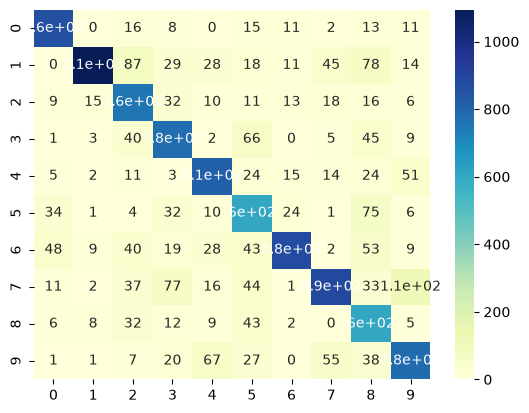

In [6]:
confusion_matrix = [[0 for _ in range(len(output_layer))] for _ in range(len(output_layer))]
correct = 0
for c in range(len(x_test)):
    input_vector = image2vector(x_test[c])  # Convert the input image to a vector
    input_vector.append(1)
    net_input = [dot(input_vector, weights[0][j]) for j in range(output_layer_size)]
    output_layer = [A * math.tanh(S * net_input[j]) for j in range(output_layer_size)]  # Compute the output of the first hidden layer for the first training image
    output_key = output_layer.index(max(output_layer))
    if output_key == y_test[c]:
        confusion_matrix[y_test[c]][y_test[c]] += 1
        correct += 1
    else:
        confusion_matrix[output_key][y_test[c]] += 1

sns.heatmap(confusion_matrix, annot=True, cmap="YlGnBu")
error = correct/len(x_test)
plt.show()

In [7]:
print("Test Dataset Accuracy: " + str(error))

Test Dataset Accuracy: 0.8059


In [8]:
data_folder = Path("Data")
data_folder.mkdir(exist_ok=True)  # Create the folder if it doesn't exist
weights_file_path = data_folder / "Net1_weights.txt"

active_weights = weights[0]

# Write the weights to the file
with open(weights_file_path, "w") as file:
    for neuron_weights in active_weights:
        # Convert each float weight to a string and join them with spaces
        line = " ".join(str(w) for w in neuron_weights)
        file.write(line + "\n")

print(f"Weights successfully saved to {weights_file_path}")

Weights successfully saved to Data\Net1_weights.txt
